#### Combining the data that we have prevviously had to the new timestamp data

In [219]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely as sp
import numpy as np
from funcs import *

In [2]:
data= pd.read_csv(r"..\Data\Palmyra Data\SAT_MI_FAD.csv", sep = ",") ## new data with timestamps at each poit
data2 = gpd.read_parquet(r"..\Data\Palmyra Data\MI_and_SAT_FAD_Cleaned.parquet") ## This is the data that I have previously 


C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_5624\503539525.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  data= pd.read_csv(r"..\Data\Palmyra Data\SAT_MI_FAD.csv", sep = ",")


In [3]:
set1 = set(data["BuoyName"])
set2 = set(data2["BuoyName"])

ids = set2-set1
print(len(ids))


filtered = data2["BuoyName"].isin(ids)

ds = data2[filtered]
print(data["MinOfTimes"].max())
print(data2["MinOfDate"].max())
ds.to_parquet(r"..\Data\Palmyra Data\dFADS_missing_time.parquet")

74
2025-09-24 18:57:00
2024-06-28 00:00:00


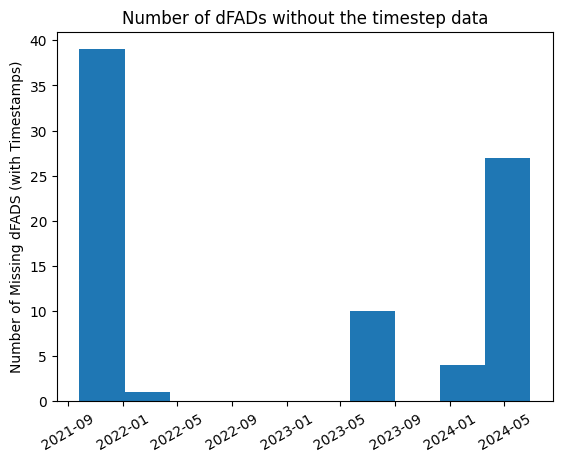

In [280]:
fig, ax = plt.subplots()
ax.hist(ds["MinOfDate"])
ax.set_ylabel("Number of Missing dFADS (with Timestamps)")
ax.set_title("Number of dFADs without the timestep data")
ax.tick_params(axis = "x", rotation = 30)
fig.savefig(r"C:\FATE\Figures\Missing_TimeStamp_data.png")

#### Converting from CSV to to parquet with geometry objects. 

In [5]:
data= pd.read_csv(r"..\Data\Palmyra Data\SAT_MI_FAD.csv", low_memory=False )

In [6]:
print(data2["geometry"][0])

LINESTRING (-163.57694999999998 4.794720000000041, -163.54817999999997 4.782150000000058, -163.51237999999998 4.793730000000039, -163.48122999999998 4.79445000000004, -163.45762999999997 4.790870000000041, -163.42601999999997 4.795600000000036, -163.39084999999997 4.78212000000002, -163.36131999999998 4.7596000000000345, -163.33182999999997 4.770820000000072, -163.30552999999998 4.77818000000002, -163.28556999999998 4.7906300000000215, -163.25612999999998 4.816100000000063, -163.23356999999996 4.822280000000035, -163.20249999999996 4.834130000000073, -163.16289999999998 4.865270000000066, -163.12576999999996 4.877580000000023, -163.09311999999997 4.895450000000039, -163.04844999999997 4.9262200000000576, -163.00654999999998 4.94193000000007, -162.97582999999997 4.950130000000058, -162.92557999999997 4.977280000000064, -162.88664999999997 4.99043000000006, -162.85799999999998 5.0057200000000535, -162.81684999999996 5.036670000000072, -162.76747999999998 5.0423300000000495, -162.72536999

In [7]:
Latitude_list = data.groupby("BuoyName")["Latitude"].apply(list)
Longitude_list = data.groupby("BuoyName")["Longitude"].apply(list)
times_list = data.groupby("BuoyName")["Timestamp"].apply(list)
date_enter = data.groupby("BuoyName")["MinOfTimes"].apply(np.minimum.reduce)
date_exit = data.groupby("BuoyName")["MaxOfTimes"].apply(np.minimum.reduce)
BuoyNames = data["BuoyName"].unique()

print(len(Latitude_list))
mask = Latitude_list.apply(len) != 1
Latitude_list = Latitude_list[mask]
Longitude_list = Longitude_list[mask]
times_list = times_list[mask]
date_enter = date_enter[mask]
date_exit = date_exit[mask]

BuoyNames_filtered = Latitude_list.index.to_numpy()
print(len(Latitude_list))

Latitude_list
lines = []
for n in range(len(Latitude_list)):
    line = sp.linestrings(Longitude_list.iloc[n],Latitude_list.iloc[n])
    lines.append(line)


print(len(BuoyNames), len(lines), len(date_enter), len(date_exit))
newdata = gpd.GeoDataFrame({"BuoyName":BuoyNames_filtered, "MinOfDate":date_enter, "MaxOfDate": date_exit, "TimeStamp": times_list, "geometry": lines}, index= None)
newdata = newdata.reset_index(drop = True)
newdata.to_parquet(r"..\Data\Palmyra Data\SAT_MI_FAD.parquet")


3064
3003
3064 3003 3003 3003


In [8]:
data = gpd.read_parquet(r"..\Data\Palmyra Data\SAT_MI_FAD.parquet")
ds = gpd.read_parquet(r"..\Data\Palmyra Data\dFADS_missing_time.parquet")
print(ds.columns)
keep = ["BuoyName", "MinOfDate", "MaxOfDate", "geometry"]
ds = ds[keep]
ds = ds.reset_index(drop = True)
combined = pd.concat([data,ds])
combined = gpd.GeoDataFrame(combined)
combined["MinOfDate"] = pd.to_datetime(combined["MinOfDate"], format = r"%Y-%m-%d %H:%M:%S")
combined["MaxOfDate"] = pd.to_datetime(combined["MaxOfDate"], format = r"%Y-%m-%d %H:%M:%S")
combined = combined.sort_values("MinOfDate")
combined = combined.reset_index(drop = True)
combined.to_parquet(r"..\Data\Palmyra Data\SAT_MI_FAD_Missing_Times.parquet")

Index(['Shape_Leng', 'Set_3', 'BuoyName', 'Name_ID', 'MinOfTimes',
       'MaxOfTimes', 'MinOfDate', 'MaxOfDate', 'Yr_min', 'Mon_min', 'Day_min',
       'Yr_max', 'Mon_max', 'Day_max', 'Diff_days', 'Distance_n', 'geometry',
       'numpoints', 'SampleFreq', 'x_deg', 'y_deg', 'x_km', 'y_km', 'xy_km',
       'timelist', 'x_speed', 'y_speed', 'xy_speed', 'points_removed',
       'Masked_array'],
      dtype='object')


c:\FATE\.venv\Lib\site-packages\geopandas\array.py:1755: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))


#### FADS that exit the area and reenter have to be sepperated into new trajectories.

In [89]:
### Could also Check if they intersect first otherwise just ignore that line.
Boundry = sp.Polygon([(2,2),(2,-2), (-2,-2), (-2,2),(2,2)])
line = sp.LineString([(-4,0),(-3,0),(-1.5,0),(0,0),(1,1),(3,3), (2.5,1),(1.5,1),(1,1),(1.25,1) ])
section = sp.ops.split(line,Boundry)
print(section)
###  need to remove the added point on the line which is at the bounddry
section_noedges = []
for segment in section.geoms:
    print(f"orignial segment:{segment}")
    points_on_polygon= []
    points_on_polygon = [
        p for p in segment.coords
        if Boundry.boundary.distance(sp.Point(p)) < 1e-9 # A small tolerance for floating point errors
    ]
    #print(points_on_polygon)
    # Create a new line from points NOT on the polygon boundary
    new_coords = []
    new_coords = [p for p in segment.coords if p not in points_on_polygon]
    #print(new_coords)
    if len(new_coords)>1:
        line_new = sp.LineString(new_coords)
        section_noedges.append(line_new)
        print(f"Newline without boundry point:{line_new}")
   
print(f"section without edges: {section_noedges}")

section = sp.GeometryCollection(section_noedges)
print(section)
insidelist = []
for i in section.geoms:
    inside = i.within(Boundry)
    insidelist.append(inside)

true_points = [
geo
for geo, list in zip(section.geoms, insidelist)
if list
]

true_points = sp.GeometryCollection(true_points)
print(f"Line within Boundry:{true_points}")
## ALso need to return a mask of the timestamps to include with each line. 
points =[sp.Point(coord) for coord in line.coords]
points = sp.GeometryCollection(points)
mask = []
for i in points.geoms:    
     mask.append(i.within(Boundry))
print(mask)


GEOMETRYCOLLECTION (LINESTRING (-4 0, -3 0, -2 0), LINESTRING (-2 0, -1.5 0, 0 0, 1 1), LINESTRING (1 1, 2 2), LINESTRING (2 2, 3 3, 2.5 1, 2 1), LINESTRING (2 1, 1.5 1, 1.25 1), LINESTRING (1.25 1, 1 1))
orignial segment:LINESTRING (-4 0, -3 0, -2 0)
Newline without boundry point:LINESTRING (-4 0, -3 0)
orignial segment:LINESTRING (-2 0, -1.5 0, 0 0, 1 1)
Newline without boundry point:LINESTRING (-1.5 0, 0 0, 1 1)
orignial segment:LINESTRING (1 1, 2 2)
orignial segment:LINESTRING (2 2, 3 3, 2.5 1, 2 1)
Newline without boundry point:LINESTRING (3 3, 2.5 1)
orignial segment:LINESTRING (2 1, 1.5 1, 1.25 1)
Newline without boundry point:LINESTRING (1.5 1, 1.25 1)
orignial segment:LINESTRING (1.25 1, 1 1)
Newline without boundry point:LINESTRING (1.25 1, 1 1)
section without edges: [<LINESTRING (-4 0, -3 0)>, <LINESTRING (-1.5 0, 0 0, 1 1)>, <LINESTRING (3 3, 2.5 1)>, <LINESTRING (1.5 1, 1.25 1)>, <LINESTRING (1.25 1, 1 1)>]
GEOMETRYCOLLECTION (LINESTRING (-4 0, -3 0), LINESTRING (-1.5 0, 

In [95]:
import numpy as np
from shapely.geometry import LineString, Polygon, Point

def split_trajectory_in_domain(line: LineString, domain: Polygon):
    """
    Splits a LineString trajectory into sub-trajectories (LineStrings)
    that lie strictly within a polygon domain.

    Rules:
    - Only keeps original vertices (no new boundary points added).
    - Only keeps sub-trajectories with >= 2 inside vertices.
    - Mask marks original vertices that belong to a valid inside sub-trajectory.

    Parameters
    ----------
    line : shapely.LineString
        Input trajectory.
    domain : shapely.Polygon
        Polygon domain.

    Returns
    -------
    sub_trajectories : list of shapely.LineString
        List of sub-trajectories inside the domain.
    mask : np.ndarray (bool)
        Boolean mask for each vertex of the original line.
    """
    from shapely.geometry import LineString, Polygon, Point
    coords = np.array(line.coords)
    inside = np.array([domain.contains(Point(p)) for p in coords])

    sub_trajectories = []
    mask = np.zeros_like(inside, dtype=bool)

    current_segment = []
    current_indices = []

    for i, (pt, flag) in enumerate(zip(coords, inside)):
        if flag:
            current_segment.append(pt)
            current_indices.append(i)
        else:
            # if segment ended, check length
            if len(current_segment) >= 2:
                sub_trajectories.append(LineString(current_segment))
                mask[current_indices] = True
            # reset
            current_segment = []
            current_indices = []

    # final check at end
    if len(current_segment) >= 2:
        sub_trajectories.append(LineString(current_segment))
        mask[current_indices] = True

    return sub_trajectories, mask


Mask of inside vertices: [False  True  True  True False False False  True  True  True]
Number of inside sub-trajectories: 2
 Sub-trajectory 0: [(2.0, 1.0), (2.0, 2.0), (3.0, 3.0)]
 Sub-trajectory 1: [(2.0, 1.0), (2.0, 2.0), (3.0, 3.0)]


In [96]:
# Example usage

domain = Polygon([(0,0), (4,0), (4,4), (0,4)])
traj = LineString([(-1,1), (2,1),(2,2), (3,3),(5,1), (2,2), (2,5),  (2,1),(2,2), (3,3)])  # original trajectory

sub_trajs, mask = split_trajectory_in_domain(traj, domain)

print("Mask of inside vertices:", mask)
print("Number of inside sub-trajectories:", len(sub_trajs))
for i, st in enumerate(sub_trajs):
    print(f" Sub-trajectory {i}:", list(st.coords))

Mask of inside vertices: [False  True  True  True False False False  True  True  True]
Number of inside sub-trajectories: 2
 Sub-trajectory 0: [(2.0, 1.0), (2.0, 2.0), (3.0, 3.0)]
 Sub-trajectory 1: [(2.0, 1.0), (2.0, 2.0), (3.0, 3.0)]


In [101]:
array = np.random.randint(0,10,10)

def segment_array_by_mask(array, mask):
    segments = []
    current = []

    for val, flag in zip(array, mask):
        if flag:
            current.append(val)
        else:
            if len(current) >= 2:
                segments.append(np.array(current))
            current = []
    if len(current) >= 2:
        segments.append(np.array(current))

    return segments

segments = segment_array_by_mask(array,mask)
print(segments[1])

[4 8 5]


In [234]:
data = gpd.read_parquet(r"..\Data\Palmyra Data\SAT_MI_FAD_Missing_Times.parquet")

In [225]:
boundry = sp.Polygon([(-163.75,4.5), (-163.75,7.8), (-160 +2/3, 7.8),(-160 +2/3, 4.5)])

In [166]:
import shapely.plotting

In [253]:
def remove_outof_domain(data:gpd.GeoDataFrame):
    boundry = sp.Polygon([(-163.75,4.5), (-163.75,7.8), (-160 +2/3, 7.8),(-160 +2/3, 4.5)])
    Values = []
    for n in range(len(data)):
        line = data["geometry"][n]
        lines , mask = split_trajectory_in_domain(line, domain = boundry)
        if len(lines) <1:
            Values.append(n)
    print(Values)
    data = data.drop(Values, axis = 0)
    data = data.reset_index()
    return data


In [235]:
Values = []
for n in range(len(data)):
    line = data["geometry"][n]
    lines , mask = split_trajectory_in_domain(line, domain = boundry)
    if len(lines) <1:
        Values.append(n)
print(Values)
data = data.drop(Values, axis = 0)

[0, 1, 2, 3, 4, 16]


#### Getting exact speeds 

In [254]:
def remove_no_TimeStamp(data):
    data, xdistance, ydistance = add_distance_collumns(data)
    data = data.dropna(subset=["TimeStamp"])
    data = data.reset_index()
    return data

In [ ]:
def add_delta_time_collums(data:gpd.GeoDataFrame):
    """Adds a collum that has a list of the change in times, Removes Time stamps that are Nan"""
    Times = []
    for i in range(len(data)):
        timelist = data.at[i, "TimeStamp"]
        timelist = pd.to_datetime(timelist, format = r"%Y-%m-%d %H:%M:%S")
        deltatime = np.diff(timelist)/10**9 ## converts from nano seconds
        Times.append(deltatime)
    data["Delta_Timestamps"] = Times
    return data
        

In [271]:
def Add_x_y_speed_collums_TimeStamp(data): 
    """Converts distances in x, y, and xy to speeds in x,y,xy in m/s, using the sampleing frequency"""
    convert = 1000 ## km/hr to m/s 

    xspeeds = []
    yspeeds = []
    xyspeeds = []
    for i in data.index:
        xdistance = np.array(data.at[ i, "x_km"])
        xspeed = xdistance/data.at[i,"Delta_Timestamps"].astype("float64")*convert
        xspeeds.append(xspeed)

        ydistance = np.array(data.at[i, "y_km"])
        yspeed = ydistance/data.at[i,"Delta_Timestamps"].astype("float64")*convert
        yspeeds.append(yspeed)

        xydistance = np.array(data.at[i,"xy_km"])
        xyspeed = xydistance/data.at[i,"Delta_Timestamps"].astype("float64")*convert
        xyspeeds.append(xyspeed)

    data["x_speed"] = xspeeds
    data["y_speed"] = yspeeds
    data["xy_speed"] = xyspeeds
    return data

In [273]:
### ONLY NEED TO RUN ONCE 
data = gpd.read_parquet(r"..\Data\Palmyra Data\SAT_MI_FAD_Missing_Times.parquet")
data = remove_outof_domain(data)
data.to_parquet(r"..\Data\Palmyra Data\SAT_MI_FAD_Missing_Times.parquet")


[0, 1, 2, 3, 4, 16]


In [274]:
data = gpd.read_parquet(r"..\Data\Palmyra Data\SAT_MI_FAD_Missing_Times.parquet")
data, xdistance, ydistance = add_distance_collumns(data)
data = remove_no_TimeStamp(data)
data = add_delta_time_collums(data)

c:\FATE\Code\functions\funcs.py:225: RuntimeWarning: divide by zero encountered in divide
  heading = np.atan(delx_long/dely_long)
c:\FATE\Code\functions\funcs.py:225: RuntimeWarning: invalid value encountered in divide
  heading = np.atan(delx_long/dely_long)


2997


In [275]:
data = Add_x_y_speed_collums_TimeStamp(data)

C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_5624\442186009.py:10: RuntimeWarning: invalid value encountered in divide
  xspeed = xdistance/data.at[i,"Delta_Timestamps"].astype("float64")*convert
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_5624\442186009.py:14: RuntimeWarning: divide by zero encountered in divide
  yspeed = ydistance/data.at[i,"Delta_Timestamps"].astype("float64")*convert
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_5624\442186009.py:14: RuntimeWarning: invalid value encountered in divide
  yspeed = ydistance/data.at[i,"Delta_Timestamps"].astype("float64")*convert
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_5624\442186009.py:18: RuntimeWarning: divide by zero encountered in divide
  xyspeed = xydistance/data.at[i,"Delta_Timestamps"].astype("float64")*convert
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_5624\442186009.py:18: RuntimeWarning: invalid value encountered in divide
  xyspeed = xydistance/data.at[i,"Delta_Timestamps"].astype("float64")*co